#Model 1A: Gravity only simulation
#Gravity only, no drag, no spin, no swing

In [46]:
import numpy as np
import matplotlib.pyplot as plt

In [47]:
#Simulation #1: Basic simulation with only gravity. No drag, spin or bounce yet.

#Initial conditions:
X0 = 0
Y0 = 2.0
v0 = 30.0
theta_deg = -5.0
g = 9.80
dt = 0.001

#X0 is set to zero as the release point of the bowler is considered to be the
#start point. Y0 is set to 2.0 m to account for the height that the bowlers arm
#reaches as they are about to release the ball. V0 is the initial velocity which
#is the pace of the bowler. Initial angle is negative since the bowler bowls
#downward toward the pitch. g is the acceleration due to gravity and dt is the
#time step we are using.

#Initial values setup
theta = np.radians(theta_deg) #Degrees to radians
vx = v0*np.cos(theta)         #Initial X - velocity
vy = v0*np.sin(theta)         #Initial Y - velocity

x = X0
y = Y0    #The three initial conditions
t = 0

#List of values
x_value = [X0]
y_value = [Y0]
t_value = [0]

#Simulation
while y > 0:
  x = x + vx*dt   #Updating position
  y = y + vy*dt

  vy = vy - g*dt     #Changing Y-velocity
  t = t + dt         #Changing time

#Storing values in list
  x_value.append(x)
  y_value.append(y)
  t_value.append(t)

#Displaying results
print(f"Time until ball reaches pitch: {t:.2f} seconds")
print(f"Distance traveled: {x:.2f} meters")

Time until ball reaches pitch: 0.43 seconds
Distance traveled: 12.73 meters


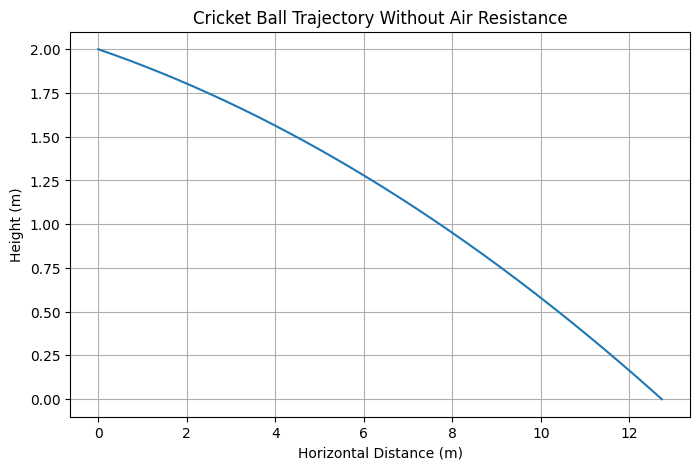

In [48]:
#Plot generation
import os
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(x_value, y_value)

plt.title("Cricket Ball Trajectory Without Air Resistance")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Height (m)")

plt.grid(True)
plt.savefig("figures/basic_projectile_motion.png", dpi=300, bbox_inches="tight")
plt.show()

## Model 1A Summary

This first model simulates the motion of a cricket ball under gravity only. The model ignores air resistance, swing, spin, and bounce. The purpose is to create a trajectory that later models can be compared against.

Key assumptions:
- The ball is treated as a point mass.
- Gravity is constant.
- There is no air resistance.
- There is no spin or swing.
- The simulation stops when the ball reaches the pitch.

In [49]:
print(f"Initial speed: {v0} m/s")
print(f"Release angle: {theta_deg} degrees")
print(f"Release height: {Y0} m")
print(f"Time until ball reaches pitch: {t:.2f} seconds")
print(f"Horizontal distance traveled: {x:.2f} meters")

Initial speed: 30.0 m/s
Release angle: -5.0 degrees
Release height: 2.0 m
Time until ball reaches pitch: 0.43 seconds
Horizontal distance traveled: 12.73 meters


#Model 1B: Simple bounce model
#Gravity only, no drag, no spin, no swing

In [50]:
#Model 1B: Simple bounce

# Initial conditions
x = X0
y = Y0
t = 0

e = 0.6  # coefficient of restitution

theta = np.radians(theta_deg)

vx = v0 * np.cos(theta)
vy = v0 * np.sin(theta)

# Lists to store position and time
x_bounce_values = [x]
y_bounce_values = [y]
t_bounce_values = [t]

# Track whether the ball has bounced
has_bounced = False

while True:
    # Update position
    x = x + vx * dt
    y = y + vy * dt

    # Update vertical velocity due to gravity
    vy = vy - g * dt

    # Update time
    t = t + dt

    # First pitch contact: bounce
    if y <= 0 and not has_bounced:
        y = 0
        vy = -e * vy
        has_bounced = True

    # Second pitch contact: stop
    elif y <= 0 and has_bounced:
        y = 0
        x_bounce_values.append(x)
        y_bounce_values.append(y)
        t_bounce_values.append(t)
        break

    # Store values
    x_bounce_values.append(x)
    y_bounce_values.append(y)
    t_bounce_values.append(t)

print(f"Initial speed: {v0} m/s")
print(f"Release angle: {theta_deg} degrees")
print(f"Release height: {Y0} m")
print(f"Coefficient of restitution: {e}")
print(f"Final simulation time: {t:.2f} seconds")
print(f"Horizontal distance traveled: {x:.2f} meters")


Initial speed: 30.0 m/s
Release angle: -5.0 degrees
Release height: 2.0 m
Coefficient of restitution: 0.6
Final simulation time: 1.26 seconds
Horizontal distance traveled: 37.63 meters


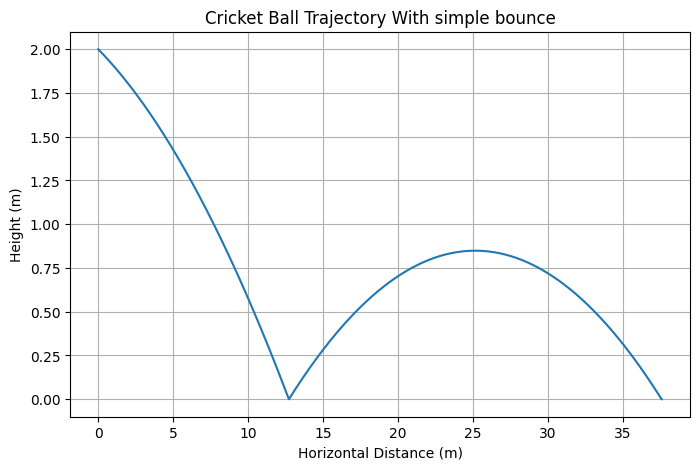

In [51]:
#Plot generation
import os
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(x_bounce_values, y_bounce_values)

plt.title("Cricket Ball Trajectory With simple bounce")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Height (m)")

plt.grid(True)
plt.savefig("figures/basic_bounce_motion.png", dpi=300, bbox_inches="tight")
plt.show()

## Model 1B Summary

This first model simulates the motion of a cricket ball under gravity only including simple bounce. The model ignores air resistance, swing, spin. The purpose is to create a trajectory that later models can be compared against.

Key assumptions:
- The ball is treated as a point mass.
- Gravity is constant.
- There is no air resistance.
- There is no spin or swing.
- The simulation stops before second contact with the pitch.

In [52]:
print(f"Initial speed: {v0} m/s")
print(f"Release angle: {theta_deg} degrees")
print(f"Release height: {Y0} m")
print(f"Time until ball reaches pitch: {t:.2f} seconds")
print(f"Horizontal distance traveled: {x:.2f} meters")
print(f"Coefficient of restitution: {e}")


Initial speed: 30.0 m/s
Release angle: -5.0 degrees
Release height: 2.0 m
Time until ball reaches pitch: 1.26 seconds
Horizontal distance traveled: 37.63 meters
Coefficient of restitution: 0.6


**Model** 2A: Projectile motion with air resistance

Gravity and air resistance only

In [53]:
# Model 2 constants

m = 0.156       # mass of cricket ball, kg
rho = 1.225     # air density, kg/m^3
Cd = 0.5        # drag coefficient, simplified assumption from NASA
r = 0.036       # radius of cricket ball, meters

A = np.pi * r**2  # cross-sectional area

In [54]:
#Initial conditions
x = X0
y = Y0
t = 0

theta = np.radians(theta_deg)
vx = v0*np.cos(theta)
vy = v0*np.sin(theta)
v = np.sqrt(vx**2 + vy**2)


#List of values
x_drag_value = [X0]
y_drag_value = [Y0]
t_drag_value = [0]

#Drag Force
F_drag = -0.5*rho*Cd*A*v**2
F_drag_x = F_drag*vx/v
F_drag_y = F_drag*vy/v

#Simulation
while y > 0:
  F_drag = -0.5*rho*Cd*A*v**2
  F_drag_x = F_drag*vx/v
  F_drag_y = F_drag*vy/v

  vx = vx + F_drag_x*dt/m    #Updating velocity
  vy = vy + (-g+F_drag_y/m)*dt

  x = x + vx*dt   #Updating position
  y = y + vy*dt

  t = t + dt         #Changing time

#Storing values in list
  x_drag_value.append(x)
  y_drag_value.append(y)
  t_drag_value.append(t)

#Displaying results
print(f"Initial speed: {v0} m/s")
print(f"Release angle: {theta_deg} degrees")
print(f"Release height: {Y0} m")
print(f"Final simulation time with drag: {t:.2f} seconds")
print(f"Horizontal distance traveled with drag: {x:.2f} meters")


Initial speed: 30.0 m/s
Release angle: -5.0 degrees
Release height: 2.0 m
Final simulation time with drag: 0.44 seconds
Horizontal distance traveled with drag: 12.45 meters


Model 2A Plot

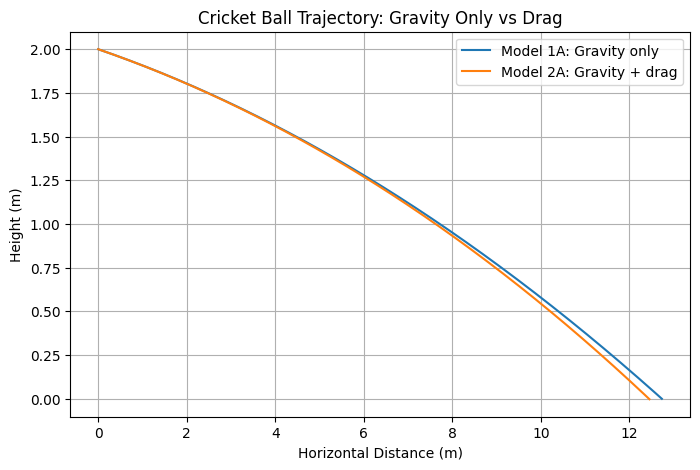

In [55]:
plt.figure(figsize=(8, 5))

plt.plot(x_value, y_value, label="Model 1A: Gravity only")
plt.plot(x_drag_value, y_drag_value, label="Model 2A: Gravity + drag")

plt.title("Cricket Ball Trajectory: Gravity Only vs Drag")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Height (m)")

plt.grid(True)
plt.legend()

plt.savefig("figures/projectile_motion_with_drag.png", dpi=300, bbox_inches="tight")

plt.show()

**Model** 2B: Projectile motion with air resistance

Gravity, air resistance and bounce

In [56]:
#Initial conditions
x = X0
y = Y0
t = 0

e = 0.6  # coefficient of restitution

theta = np.radians(theta_deg)
vx = v0*np.cos(theta)
vy = v0*np.sin(theta)

#List of values
x_drag_bounce_value = [X0]
y_drag_bounce_value = [Y0]
t_drag_bounce_value = [0]

# Track whether the ball has bounced
has_bounced = False

while True:
    v = np.sqrt(vx**2 + vy**2)
    F_drag = -0.5*rho*Cd*A*v**2     #Drag force
    F_drag_x = F_drag*vx/v if v != 0 else 0
    F_drag_y = F_drag*vy/v if v != 0 else 0

    vx = vx + F_drag_x*dt/m    #Updating velocity
    vy = vy + (-g+F_drag_y/m)*dt

    x = x + vx*dt   #Updating position
    y = y + vy*dt
    t = t + dt      #Changing time

    # First pitch contact: bounce
    if y <= 0 and not has_bounced:
        y = 0
        vy = -e * vy
        has_bounced = True

    # Second pitch contact: stop
    elif y <= 0 and has_bounced:
        y = 0
        x_drag_bounce_value.append(x)
        y_drag_bounce_value.append(y)
        t_drag_bounce_value.append(t)
        break

    # Storing values in list
    x_drag_bounce_value.append(x)
    y_drag_bounce_value.append(y)
    t_drag_bounce_value.append(t)

#Displaying results
print(f"Initial speed: {v0} m/s")
print(f"Release angle: {theta_deg} degrees")
print(f"Release height: {Y0} m")
print(f"Final simulation time with drag: {t:.2f} seconds")
print(f"Horizontal distance traveled with drag: {x:.2f} meters")

Initial speed: 30.0 m/s
Release angle: -5.0 degrees
Release height: 2.0 m
Final simulation time with drag: 1.21 seconds
Horizontal distance traveled with drag: 31.68 meters


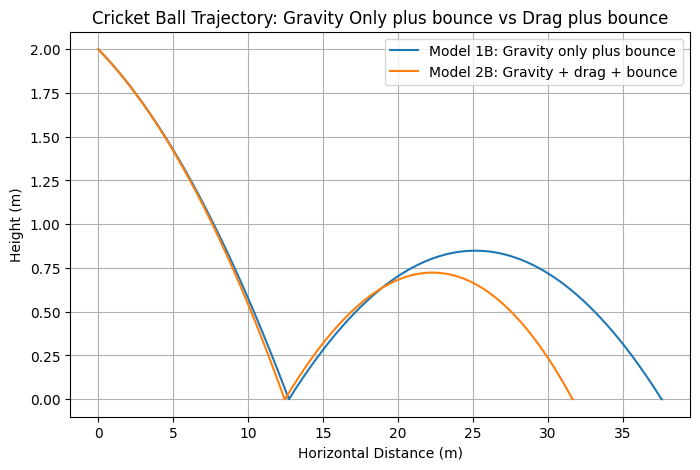

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(x_bounce_values, y_bounce_values, label="Model 1B: Gravity only plus bounce")
plt.plot(x_drag_bounce_value, y_drag_bounce_value, label="Model 2B: Gravity + drag + bounce")

plt.title("Cricket Ball Trajectory: Gravity Only plus bounce vs Drag plus bounce")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Height (m)")

plt.grid(True)
plt.legend()

plt.savefig("figures/projectile_motion_with_drag_bounce.png", dpi=300, bbox_inches="tight")

plt.show()